# Compiling COMPASS Jurisdiction GeoPackage

To being with, download the required data:

- State shapefile: https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_500k.zip
- County shapefile: https://www.census.gov/geographies/mapping-files/time-series/geo/carto-boundary-file.html
- Subdivision shapefile: https://public.opendatasoft.com/explore/dataset/georef-united-states-of-america-county-subdivision/table/?flg=en-us&disjunctive.ste_code&disjunctive.ste_name&disjunctive.coty_code&disjunctive.coty_name&disjunctive.cousub_code&disjunctive.cousub_name&sort=year"
- Place shapefile: https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_place_500k.zip
- Info for parish fix: https://transition.fcc.gov/oet/info/maps/census/fips/fips.txt


In [1]:
from pyproj.network import set_network_enabled

# Disable network updates for grids
set_network_enabled(active=False)

In [2]:
import unicodedata

from tqdm.auto import tqdm
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_500k.zip"
)
cnty = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_500k.zip"
)
subd = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2025/shp/cb_2025_us_cousub_500k.zip"
)
place = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_place_500k.zip"
)

ERROR 1: PROJ: proj_create_from_database: Open of /home/ppinchuk/workspace_compass/.pixi/envs/pdev/share/proj failed


In [4]:
# jurisdictions to remove entirely from collection
remove = [
    "Commonwealth of the Northern Mariana Islands",
    "American Samoa",
    "Guam",
    "Puerto Rico",
    "United States Virgin Islands",
]

## Data conversions

Now that the data is loaded, clean each file and align columns:

In [5]:
# https://www.census.gov/library/reference/code-lists/legal-status-codes.htm
lsad_mapping = {
    "00": None,
    "20": "barrio",
    "21": "borough",
    "22": "CCD",
    "23": "census subarea",
    "24": "census subdistrict",
    "25": "city",
    "26": "county",
    "27": "district",
    "28": "district",
    "29": "precinct",
    "30": "precinct",
    "31": "gore",
    "32": "grant",
    "35": "metro township",
    "36": "location",
    "37": "municipality",
    "39": "plantation",
    "41": "barrio-pueblo",
    "42": "purchase",
    "43": "town",
    "44": "township",
    "45": "township",
    "46": "UT",
    "47": "village",
    "49": "charter township",
    "53": "city and borough",
    "55": "comunidad",
    "57": "CDP",
    "62": "zona urbana",
    "86": "reservation",
    "CG": "consolidated government",
    "CN": "corporation",
    "MG": "metropolitan government",
    "UC": "urban county",
    "UG": "unified government",
}

subd = subd.rename(
    columns={
        "STATEFP": "state_fips",
        "STATE_NAME": "state_name",
        "COUNTYFP": "county_fips",
        "NAME": "subd_name",
        "GEOID": "subd_fips",
    }
)
for_subd = cnty[["GEOID", "NAME"]].rename(
    columns={"GEOID": "for_merge_fips", "NAME": "county_name"}
)
subd["for_merge_fips"] = subd.apply(
    lambda row: f"{row['state_fips']}{row['county_fips']}", axis=1
)
subd = subd.merge(for_subd, on=["for_merge_fips"], how="left")
mask = (
    (subd["county_name"].isna())
    & (subd["state_name"].isin({"Connecticut", "Alaska"}))
)
subd.loc[mask, "county_name"] = subd.loc[mask].apply(
    lambda row: " ".join(row["NAMELSADCO"].split(" ")[:-2]), axis=1
)
subd["subd_type"] = subd.apply(lambda row: lsad_mapping[row["LSAD"]], axis=1)

In [6]:
subd = subd[
    [
        'state_name',
        'state_fips',
        'county_fips',
        'county_name',
        'subd_name',
        'subd_fips',
        'subd_type',
        'geometry'
    ]
]

state_fips_table = (
    subd
    .groupby(['state_fips', 'state_name'])
    .first()
    .reset_index()[['state_fips', 'state_name',]]
)
subd = subd[~(subd.state_name.isin(remove))]
subd[subd["county_name"].isna()][["state_name"]].value_counts()

Series([], Name: count, dtype: int64)

In [7]:
place = place.rename(
    columns={
        "STATEFP": "state_fips",
        "STATE_NAME": "state_name",
        # "COUNTYFP": "county_fips",
        "NAME": "subd_name",
        "GEOID": "subd_fips",
    }
)
place["county_name"] = None
place["county_fips"] = None
place["subd_type"] = place.apply(lambda row: lsad_mapping[row["LSAD"]], axis=1)

In [8]:
place = place[
    [
        'state_name',
        'state_fips',
        'county_fips',
        'county_name',
        'subd_name',
        'subd_fips',
        'subd_type',
        'geometry'
    ]
]

place = place[~(place.state_name.isin(remove))]

In [9]:
# clean up names, transform geom, get names where needed from
# subdivision dataset
cnty['state_fips'] = pd.to_numeric(cnty['STATEFP'])
cnty['county_fips'] = cnty['COUNTYFP']
cnty['county_name'] = cnty['NAME']
cnty['subd_fips'] = cnty['GEOID']
cnty = cnty.to_crs(subd.crs)
state_fips_table["state_fips"] = state_fips_table["state_fips"].astype(int)

cnty = cnty.merge(state_fips_table, on='state_fips', how='left')

In [10]:
cnty = cnty[
    [
        'state_name',
        'state_fips',
        'county_name',
        'county_fips',
        'subd_fips',
        'geometry'
    ]
]
cnty = cnty[~(cnty.state_name.isin(remove))]
cnty["subd_type"] = "county"

In [11]:
states = states[~(states.NAME.isin(remove))].reset_index(drop=True)
states["STATEFP"] = states["STATEFP"].astype(int)
states = states.rename(
    columns={"NAME": "state_name", "STATEFP": "state_fips"}
)
states["subd_fips"] = states["state_fips"] * 1000
states["subd_type"] = "state"
states = states[
    [
        'state_name',
        'state_fips',
        'subd_fips',
        'subd_type',
        'geometry'
    ]
].to_crs(subd.crs)

In [12]:
# Have to handle subdivisions + places carefully to avoid duplicate entries

def _normalize_jurisdiction_name(name):
    """Normalize jurisdiction names for resilient comparisons"""
    if name is None or pd.isna(name):
        return ""

    normalized_name = unicodedata.normalize("NFKD", str(name).casefold())
    return "".join(char for char in normalized_name if char.isalnum())


replacements = {}
to_drop_place_fips = set()
to_drop_subd_fips = set()
merged_rows = []

for __, place_row in tqdm(place.iterrows(), total=len(place)):
    place_geom = gpd.GeoSeries([place_row.geometry], crs=place.crs).to_crs(
        subd.crs
    )
    intersecting_subd = subd.loc[subd.intersects(place_geom.iloc[0])].copy()
    if len(intersecting_subd) == 0:
        msg = (
            "No matching subdivisions found for place "
            f"{place_row['subd_name']} in state {place_row['state_name']}"
        )
        raise ValueError(msg)

    place_name = _normalize_jurisdiction_name(place_row["subd_name"])
    matching_subd = intersecting_subd.loc[
        intersecting_subd["subd_name"].map(_normalize_jurisdiction_name)
        == place_name
    ]
    if len(matching_subd) == 0:
        continue

    matching_subd = matching_subd.copy()
    # match_resolution = resolve_place_match(place_row, matching_subd)
    to_drop_place_fips.add(place_row["subd_fips"])
    to_drop_subd_fips.update(matching_subd["subd_fips"].tolist())

    merged_row = place_row.copy()
    merged_row["geometry"] = matching_subd.geometry.union_all()

    counties = matching_subd["county_name"].dropna().unique()
    if len(counties) == 1:
        merged_row["county_name"] = matching_subd.iloc[0]["county_name"]
        merged_row["county_fips"] = matching_subd.iloc[0]["county_fips"]

    merged_rows.append(merged_row)

    for matched_subd_type in matching_subd["subd_type"].dropna().unique():
        replacements.setdefault(matched_subd_type, {}).setdefault(
            place_row["subd_type"], set()
        ).add(place_row["subd_fips"] )

merged = gpd.GeoDataFrame(
    merged_rows, columns=place.columns, geometry="geometry", crs=place.crs
)
merged.head()

  0%|          | 0/32041 [00:00<?, ?it/s]

,state_name,state_fips,county_fips,county_name,subd_name,subd_fips,subd_type,geometry
0,Florida,12,127,Volusia,Ormond Beach,1253150,city,"POLYGON ((-81.15588 29.41095, -81.14815 29.411..."
1,Illinois,17,153,Pulaski,Olmsted,1755899,village,"POLYGON ((-89.14589 37.1828, -89.14579 37.2336..."
5,Alabama,01,133,Winston,Haleyville,0132704,city,"POLYGON ((-87.63657 34.12508, -87.6359 34.1424..."
6,Michigan,26,021,Berrien,Bridgman,2610580,city,"POLYGON ((-86.59105 41.92874, -86.58866 41.932..."
8,New Jersey,34,025,Monmouth,Bradley Beach,3406970,borough,"POLYGON ((-74.02126 40.19749, -74.02029 40.200..."


In [13]:
len(to_drop_place_fips), len(to_drop_subd_fips)

(10743, 12068)

In [14]:
{k: {x: len(y) for x, y in z.items()} for k, z in replacements.items()}

{'CCD': {'city': 2106,
  'town': 710,
  'village': 20,
  'CDP': 445,
  None: 1,
  'metro township': 1},
 'precinct': {'village': 126, 'city': 51, 'CDP': 10},
 'city': {'city': 2592, 'village': 3},
 'borough': {'borough': 1204},
 'district': {'town': 43, 'city': 11, 'CDP': 45},
 'township': {'city': 1363,
  'village': 540,
  'town': 290,
  'borough': 98,
  'CDP': 344},
 'town': {'village': 365, 'town': 172, 'city': 144, 'CDP': 593, 'borough': 4},
 'village': {'village': 503, 'CDP': 1, 'city': 3},
 'UT': {'city': 9, 'CDP': 4, 'town': 1},
 'charter township': {'city': 30, 'CDP': 7, 'village': 5},
 'census subarea': {'municipality': 1,
  'CDP': 6,
  'city and borough': 3,
  'city': 4},
 'municipality': {'city': 1, 'municipality': 3},
 'plantation': {'CDP': 1}}

In [15]:
place = place.loc[~place["subd_fips"].isin(to_drop_place_fips)].copy()
subd = subd.loc[~subd["subd_fips"].isin(to_drop_subd_fips)].copy()
ord_area_frames = [states, cnty, subd, place]
if len(merged) > 0:
    merged = merged[place.columns]
    ord_area_frames.append(merged)

ord_areas = pd.concat(ord_area_frames, axis=0, ignore_index=True)
ord_areas = ord_areas[
    [
        "state_name",
        "state_fips",
        "county_name",
        "county_fips",
        "subd_name",
        "subd_fips",
        "subd_type",
        "geometry",
    ]
]
ord_areas = gpd.GeoDataFrame(ord_areas, geometry="geometry", crs=subd.crs)

## Manual cleaning

Now let's manually clean a few known problematic locations


In [16]:
# Manually adjust some entries

ord_areas.loc[ord_areas.subd_fips == "24510", "county_name"] = None
ord_areas.loc[ord_areas.subd_fips == "24510", "subd_name"] = "Baltimore"
ord_areas.loc[ord_areas.subd_fips == "24510", "subd_type"] = "city"

ord_areas.loc[ord_areas.subd_fips == "51600", "county_name"] = None
ord_areas.loc[ord_areas.subd_fips == "51600", "subd_name"] = "Fairfax"
ord_areas.loc[ord_areas.subd_fips == "51600", "subd_type"] = "city"

ord_areas.loc[ord_areas.subd_fips == "51620", "county_name"] = None
ord_areas.loc[ord_areas.subd_fips == "51620", "subd_name"] = "Franklin"
ord_areas.loc[ord_areas.subd_fips == "51620", "subd_type"] = "city"

ord_areas.loc[ord_areas.subd_fips == "51760", "county_name"] = None
ord_areas.loc[ord_areas.subd_fips == "51760", "subd_name"] = "Richmond"
ord_areas.loc[ord_areas.subd_fips == "51760", "subd_type"] = "city"

ord_areas.loc[ord_areas.subd_fips == "51770", "county_name"] = None
ord_areas.loc[ord_areas.subd_fips == "51770", "subd_name"] = "Roanoke"
ord_areas.loc[ord_areas.subd_fips == "51770", "subd_type"] = "city"

ord_areas.loc[ord_areas.subd_fips == "29510", "county_name"] = None
ord_areas.loc[ord_areas.subd_fips == "29510", "subd_name"] = "St. Louis"
ord_areas.loc[ord_areas.subd_fips == "29510", "subd_type"] = "city"

In [17]:
# Fix for parishes, boroughs, and census areas

fips_to_type = pd.read_csv(
    "fips_to_type.txt",
    delimiter="      ",
    header=None,
    names=["fips", "type"],
    dtype={"fips": str, "type": str}
)
mask = fips_to_type["type"].str.lstrip().str.split(" ").apply(len) > 1
fips_to_type = fips_to_type[mask].reset_index(drop=True)
fips_to_type["type"] = (
    fips_to_type["type"]
    .str.lstrip()
    .str.rstrip()
    .str.split(" ")
    .apply(lambda x: x[-1].casefold())
)


parish_fips = set(fips_to_type.loc[fips_to_type["type"] == "parish", "fips"])
parish_mask = ord_areas["subd_fips"].isin(parish_fips)
ord_areas.loc[parish_mask, "subd_type"] = "parish"

fips_borough_mask = (
    (fips_to_type["fips"].str.startswith("02"))
    & (fips_to_type["type"] == "borough")
)
borough_fips = set(fips_to_type.loc[fips_borough_mask, "fips"])
borough_mask = ord_areas["subd_fips"].isin(borough_fips)
ord_areas.loc[borough_mask, "subd_type"] = "borough"

fips_area_mask = (
    (fips_to_type["fips"].str.startswith("02"))
    & (fips_to_type["type"] == "area")
)
area_fips = set(fips_to_type.loc[fips_area_mask, "fips"])
area_mask = ord_areas["subd_fips"].isin(area_fips)
ord_areas.loc[area_mask, "subd_type"] = "census area"

/tmp/ipykernel_43094/3448464197.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  fips_to_type = pd.read_csv(


In [18]:
# Manual Alaska adjustments
ord_areas.loc[ord_areas.subd_fips == "02158", "subd_type"] = "census area"
ord_areas.loc[ord_areas.subd_fips == "02195", "subd_type"] = "borough"
ord_areas.loc[ord_areas.subd_fips == "02230", "subd_type"] = "borough"
ord_areas.loc[ord_areas.subd_fips == "02275", "subd_type"] = "borough"
ord_areas.loc[ord_areas.subd_fips == "02198", "subd_type"] = "census area"
ord_areas.loc[ord_areas.subd_fips == "02105", "subd_type"] = "census area"


ord_areas.loc[ord_areas.subd_fips == "02261", "county_name"] = None
ord_areas.loc[ord_areas.subd_fips == "02261", "subd_name"] = "Valdez-Cordova"
ord_areas.loc[ord_areas.subd_fips == "02261", "subd_type"] = "city"

ord_areas.loc[ord_areas.subd_fips == "02070", "county_name"] = None
ord_areas.loc[ord_areas.subd_fips == "02070", "subd_name"] = "Dillingham"
ord_areas.loc[ord_areas.subd_fips == "02070", "subd_type"] = "city"

ord_areas.loc[ord_areas.subd_fips == "02050", "county_name"] = None
ord_areas.loc[ord_areas.subd_fips == "02050", "subd_name"] = "Bethel"
ord_areas.loc[ord_areas.subd_fips == "02050", "subd_type"] = "city"

ord_areas.loc[ord_areas.subd_fips == "02180", "county_name"] = None
ord_areas.loc[ord_areas.subd_fips == "02180", "subd_name"] = "Nome"
ord_areas.loc[ord_areas.subd_fips == "02180", "subd_type"] = "city"

In [19]:
# Manually adjust shorthand name
ord_areas.loc[ord_areas["subd_type"] == "UT", "subd_type"] = (
    "unorganized territory"
)
ord_areas.loc[ord_areas["subd_type"] == "CCD", "subd_type"] = (
    "census county division"
)

In [20]:
# Drop Ohio census district with duplicate name
ord_areas = ord_areas[~(ord_areas["subd_fips"] == 3915981242)]

In [21]:
known_subd_types = (
    (set(ord_areas["subd_type"]) - {"census county division", None})
    | {"valley", "island"}
)
for ind, row in ord_areas.iterrows():
    if row["subd_type"] != "census county division":
        continue
    split_name = row["subd_name"].split(" ")
    if len(split_name) <= 1:
        ord_areas.loc[ind, "subd_type"] = "city"
        continue

    last_word_in_name = split_name[-1].casefold()
    if last_word_in_name in known_subd_types:
        ord_areas.loc[ind, "subd_type"] = last_word_in_name
        ord_areas.loc[ind, "subd_name"] = " ".join(split_name[:-1])
    elif last_word_in_name in {"lake", "creek"}:
        ord_areas.loc[ind, "subd_type"] = "region"
    else:
        ord_areas.loc[ind, "subd_type"] = "city"

In [22]:
# Fix 00 LSAD codes
ord_areas.loc[ord_areas.subd_fips == 3402160900, "subd_type"] = "borough"
ord_areas.loc[ord_areas.subd_fips == 3704590686, "subd_type"] = "location"
ord_areas.loc[ord_areas.subd_fips == 5101390072, "subd_type"] = "location"

In [23]:
ord_areas.head()

,state_name,state_fips,county_name,county_fips,subd_name,subd_fips,subd_type,geometry
0,Mississippi,28,NaN,NaN,NaN,28000,state,"MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ..."
1,North Carolina,37,NaN,NaN,NaN,37000,state,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ..."
2,Oklahoma,40,NaN,NaN,NaN,40000,state,"POLYGON ((-103.00256 36.52659, -103.00219 36.6..."
3,Virginia,51,NaN,NaN,NaN,51000,state,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ..."
4,West Virginia,54,NaN,NaN,NaN,54000,state,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."


In [24]:
len(ord_areas)

58562

# Final checks

In [25]:
print(ord_areas.subd_type.value_counts())

subd_type
township                   14954
CDP                        12528
city                       11987
town                        6783
village                     3719
county                      3044
district                    2796
borough                     1239
precinct                     754
unorganized territory        291
charter township              76
parish                        64
valley                        54
state                         51
reservation                   43
region                        42
plantation                    28
census subarea                23
island                        21
grant                         10
municipality                   6
purchase                       6
census area                    6
metro township                 5
location                       4
gore                           4
city and borough               3
unified government             3
urban county                   1
metropolitan government        1


In [26]:
assert len(ord_areas["subd_fips"].unique()) == len(ord_areas)
assert len(ord_areas.groupby(["subd_fips"])) == len(ord_areas)

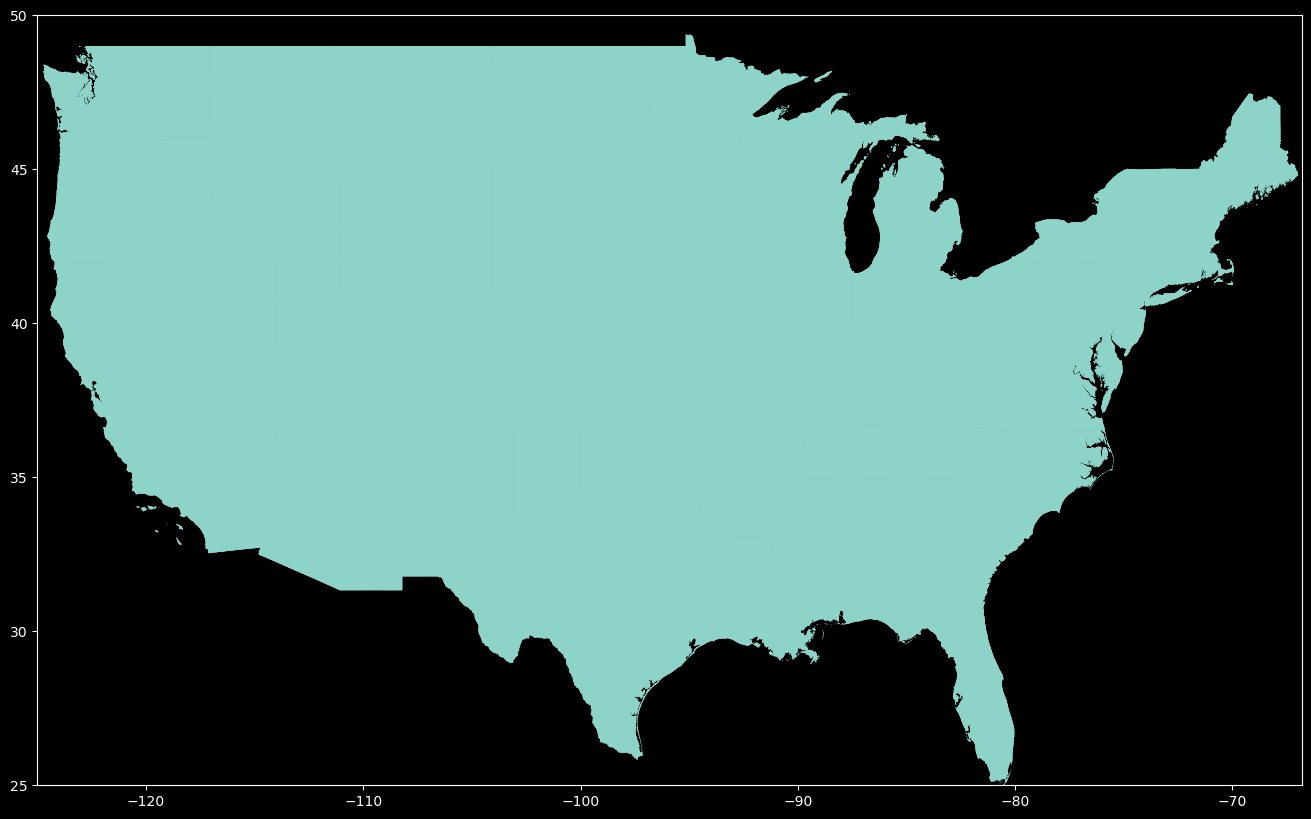

In [27]:
# All
ord_areas.plot(figsize=(20, 10))
plt.xlim(-125, -66.8)
plt.ylim(25, 50);

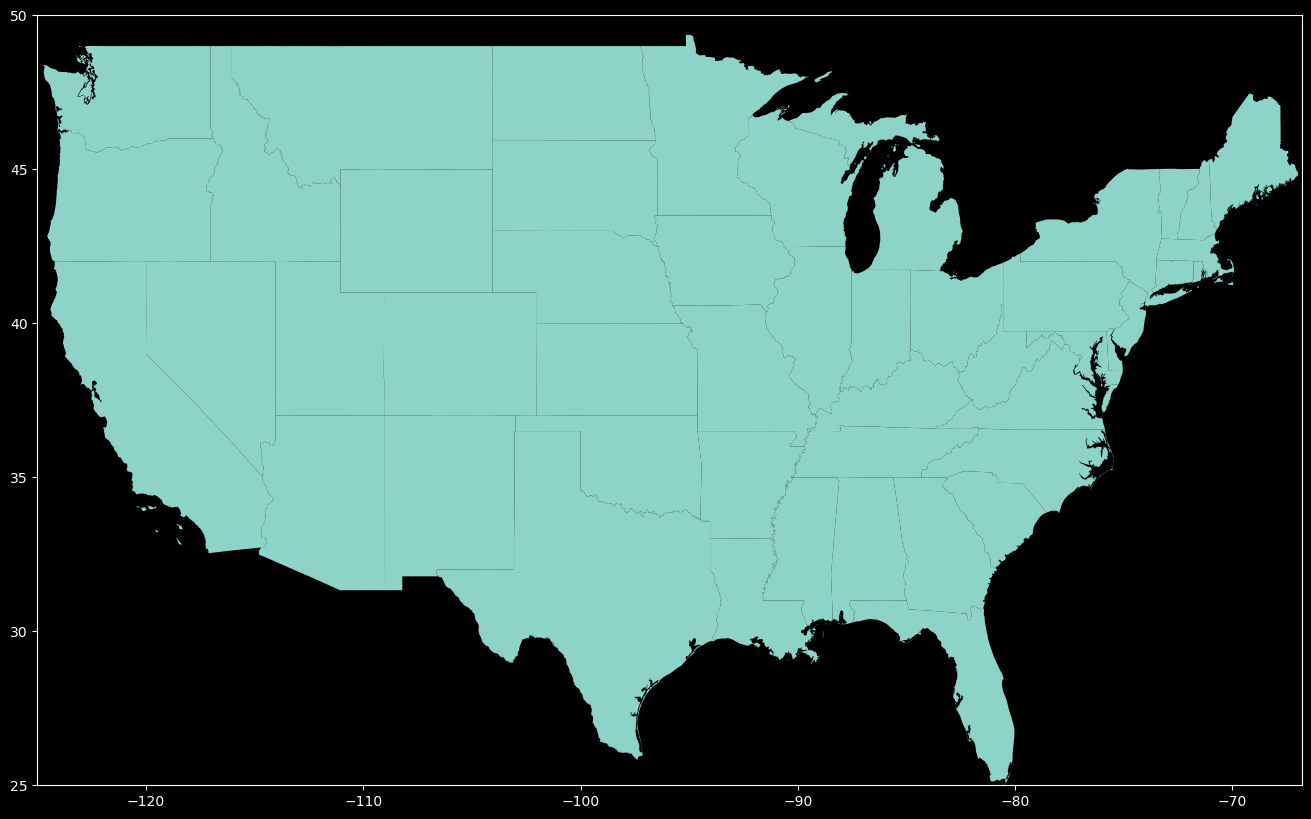

In [28]:
# States
ord_areas[ord_areas["subd_type"] == "state"].plot(figsize=(20, 10))
plt.xlim(-125, -66.8)
plt.ylim(25, 50);

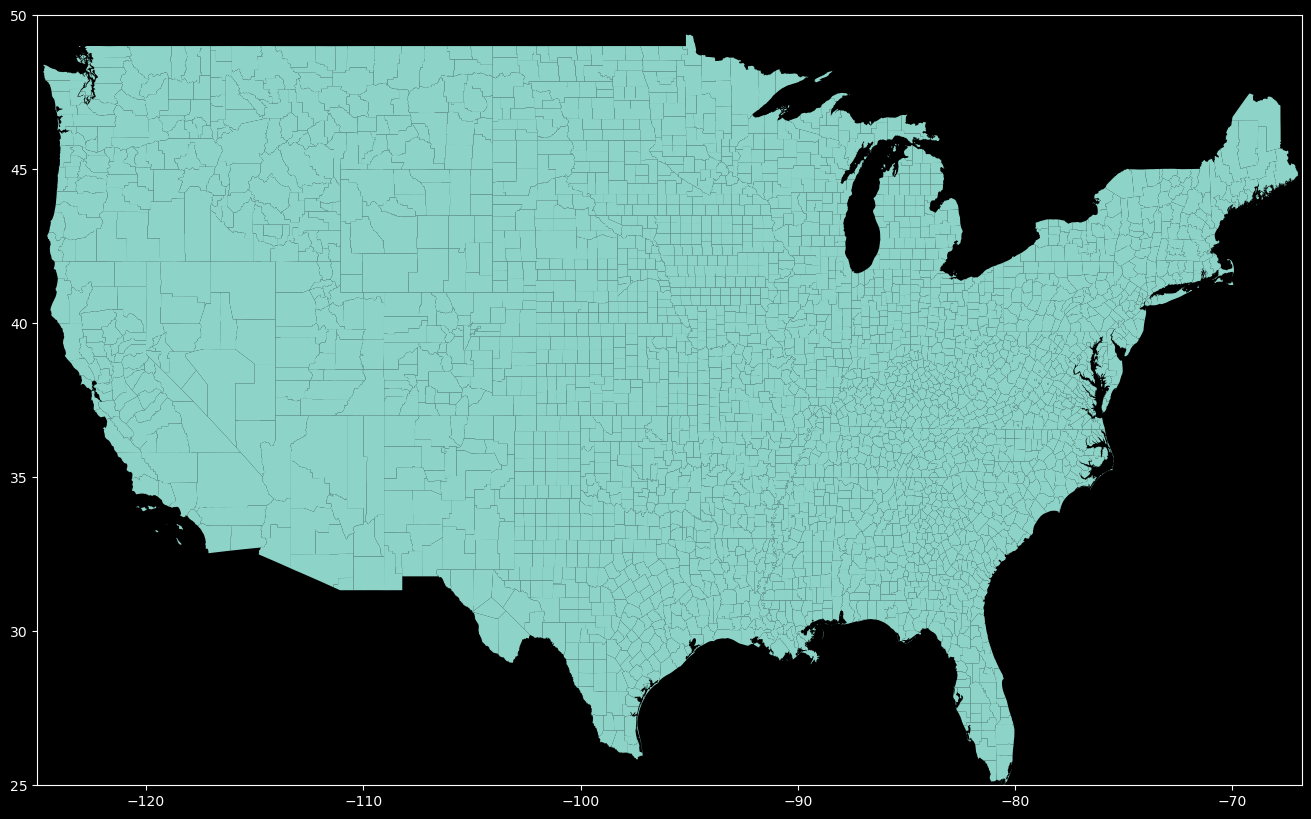

In [29]:
# Counties
ord_areas[
    (ord_areas["subd_type"] != "state")
    & (ord_areas["subd_fips"].astype(int) < 100_000)
].plot(figsize=(20, 10))
plt.xlim(-125, -66.8)
plt.ylim(25, 50);

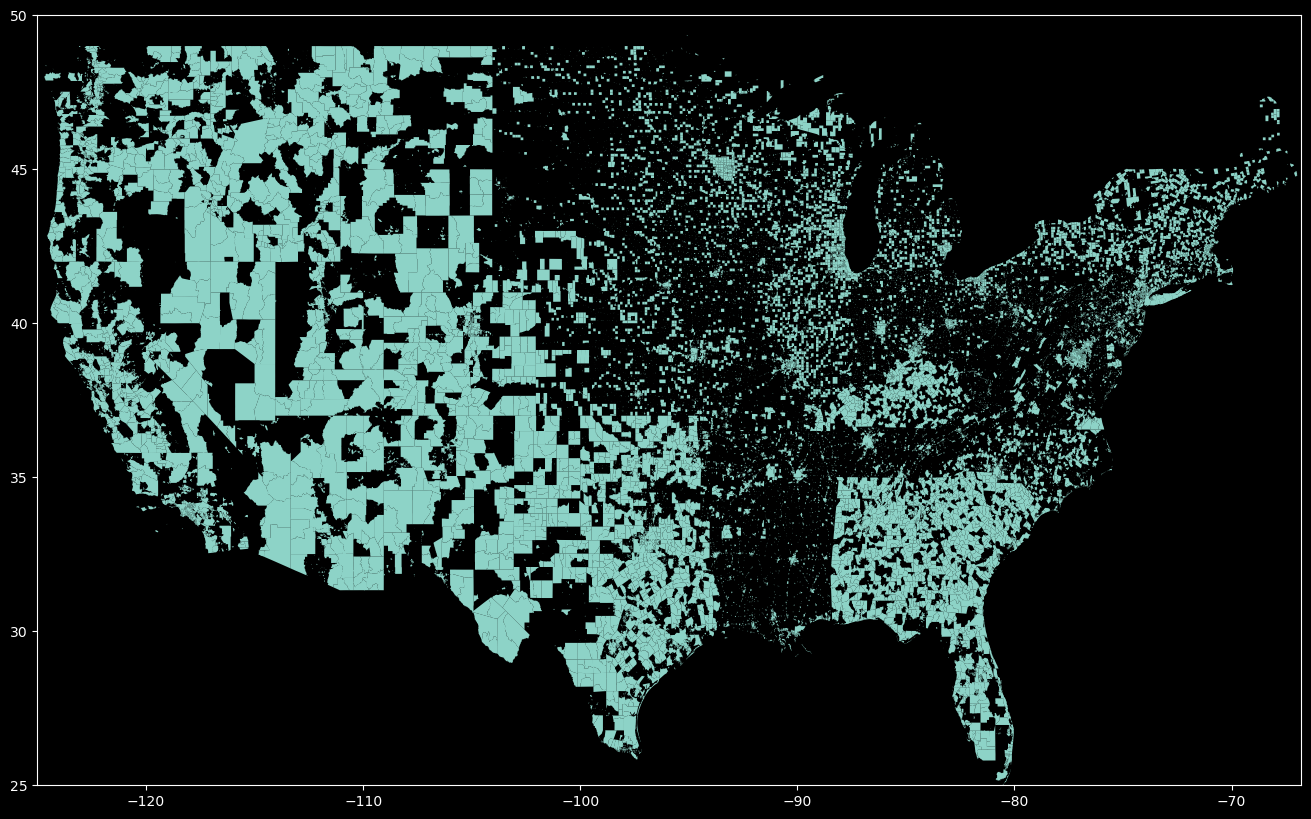

In [30]:
# Places
ord_areas[
    (ord_areas["subd_fips"].astype(int) > 100_000)
    & (ord_areas["subd_fips"].astype(int) < 10_000_000)
].plot(figsize=(20, 10))
plt.xlim(-125, -66.8)
plt.ylim(25, 50);

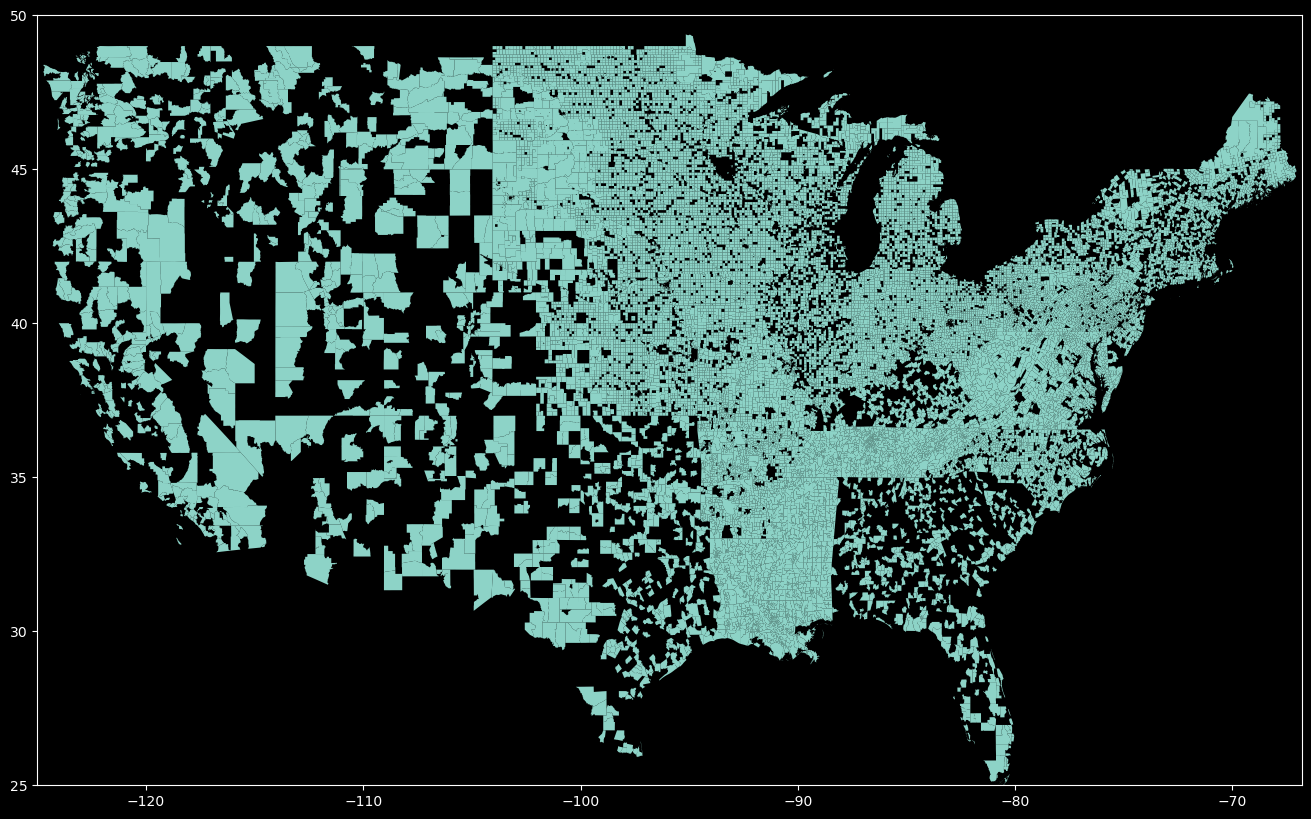

In [31]:
# Subdivisions
ord_areas[
    (ord_areas["subd_fips"].astype(int) > 10000000)
].plot(figsize=(20, 10))
plt.xlim(-125, -66.8)
plt.ylim(25, 50);

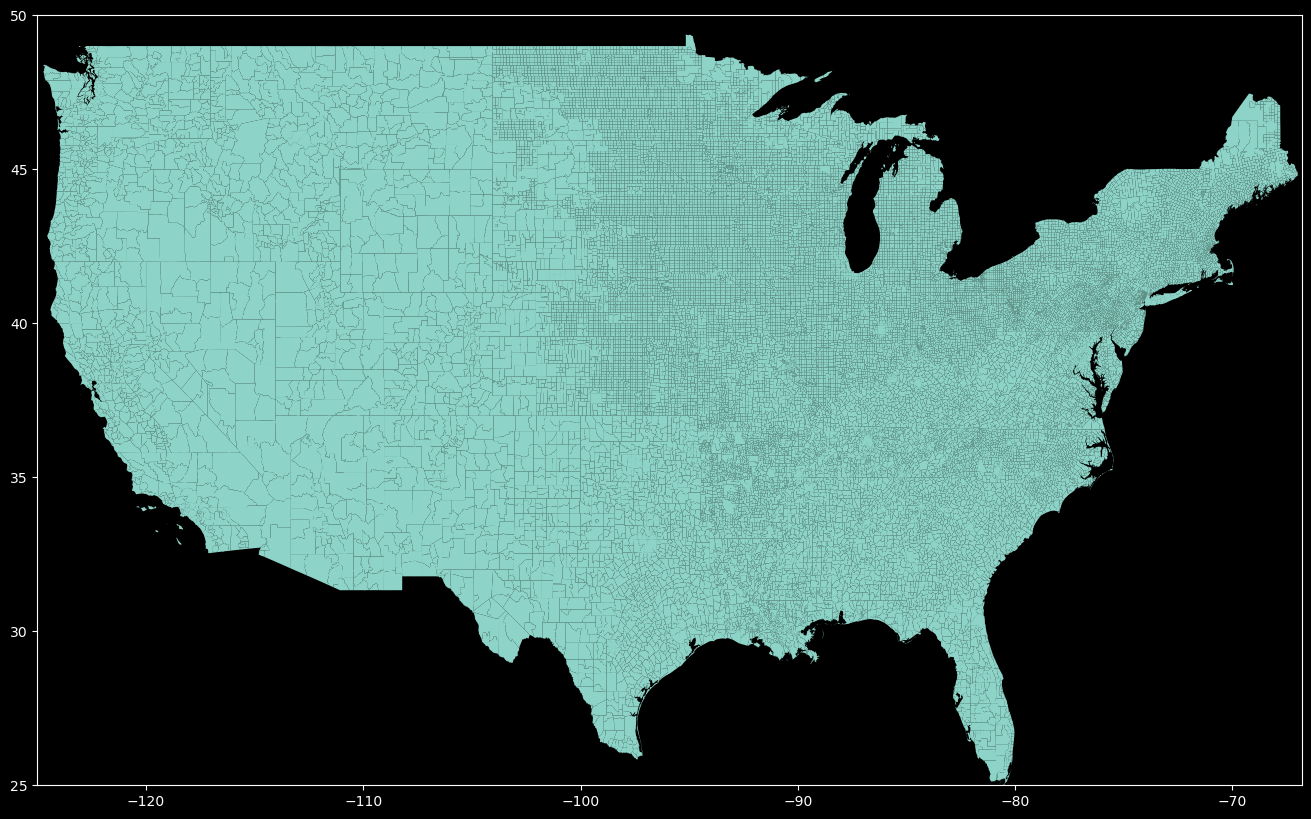

In [32]:
# Places + subdivisions
ord_areas[
    (ord_areas["subd_fips"].astype(int) > 100_000)
].plot(figsize=(20, 10))
plt.xlim(-125, -66.8)
plt.ylim(25, 50);

# Export to GeoPackage

In [33]:
ord_areas.to_file("compass_ahjs.gpkg", driver="GPKG")

# Update COMPASS data

In [ ]:
all_jurs = ord_areas.drop(columns="geometry")
all_jurs = all_jurs.rename(columns={
    "state_name": "State",
    "county_name": "County",
    "subd_name": "Subdivision",
    "subd_fips": "FIPS",
    "subd_type": "Jurisdiction Type"}
)
existing_websites = pd.read_csv(
    "../../compass/data/conus_jurisdictions.csv"
)
all_jurs["FIPS"] = all_jurs["FIPS"].apply(lambda x: f"{x:0>5}")
existing_websites["FIPS"] = existing_websites["FIPS"].apply(
    lambda x: f"{x:0>5}"
)
all_jurs = all_jurs[
    ["State", "County", "Subdivision", "Jurisdiction Type", "FIPS"]
].merge(
    existing_websites,
    on=["State", "County", "Subdivision", "Jurisdiction Type", "FIPS"],
    how="left"
)
assert all_jurs["Website"].any()
all_jurs.sort_values(by=["State", "County", "Subdivision"]).to_csv(
    "../../compass/data/conus_jurisdictions.csv",
    index=False
)